# Pipeline Data dan Arsitektur Model Deep Learning untuk Deteksi Fase Gempa

<div style="background-color:#f0f8ff; color:#111111; padding:15px; border-radius:8px;">

## Data Understanding
File <code>Stead.csv</code> (Comma-Separated Values) berfungsi sebagai tabel indeks atau katalog metadata yang berisi informasi ringkas dalam bentuk baris dan kolom teks biasa, seperti nama stasiun perekam, koordinat lokasi, perkiraan magnitudo, serta catatan waktu kedatangan gelombang. Format ini sangat ringan dan mudah dibaca langsung layaknya tabel di lembar kerja biasa, sehingga digunakan untuk menyaring dan mengelompokkan sampel rekaman mana saja yang akan diproses.  

Sementara itu, file <code>stead.HDF5</code> (Hierarchical Data Format 5) berperan sebagai tempat penyimpanan biner yang memuat matriks getaran sinyal seismik 3-komponen berdimensi besar. Keunggulan utama HDF5 adalah fitur <i>lazy loading</i>, yaitu kemampuan membaca dan menarik potongan gelombang tertentu secara instan hanya saat dipanggil tanpa perlu memuat seluruh file raksasa ke dalam memori RAM, sehingga kombinasi CSV sebagai penunjuk arah dan HDF5 sebagai penyimpan sinyal asli membuat proses komputasi menjadi sangat cepat dan efisien.

</div>

<div style="background-color:#fffacd; color:#111111; padding:15px; border-radius:8px;">

## Pipeline Data
Pipeline dibangun untuk mengambil data mentah dari arsip (HDF5), membersihkannya, dan mengubahnya menjadi format matematika yang siap dipelajari oleh model Deep Learning. Proses ini mencakup pembuangan derau instrumen dengan teknik Digital Signal Processing (DSP). Indeks waktu kedatangan P dan S dari CSV diubah menjadi kurva Gaussian berbentuk lonceng. File HDF5 di Google Drive dihubungkan secara otomatis dengan GPU Google Colab melalui fitur lazy-loading PyTorch.  

</div>

<div style="background-color:#e6ffe6; color:#111111; padding:15px; border-radius:8px;">

## Arsitektur Model
Setelah data siap, kita akan berlanjut ke pembuatan arsitektur model dirancang untuk mengenali fase gempa seakurat analis seismik manusia. Model yang digunakan adalah 1D U-Net yang mampu membaca sinyal time-series. Data dibagi menjadi kelompok belajar dan ujian. Model dilatih menggunakan optimasi agar kesalahan prediksi semakin kecil seiring berjalannya waktu.  

</div>

<div style="background-color:#ffe6e6; color:#111111; padding:15px; border-radius:8px;">

## Alur Keseluruhan
1. Tahap pertama dimulai dari data mentah yang diolah melalui pipeline. Data dibersihkan, difokuskan pada frekuensi gempa, dan diubah menjadi representasi matematis yang sesuai untuk pembelajaran mesin.  
2. Tahap berikutnya adalah memasukkan data yang sudah siap ke dalam arsitektur saraf tiruan. Model U-Net kemudian dilatih dengan strategi optimasi sehingga mampu mengenali pola fase gempa secara otomatis.  
3. Evaluasi model dengan menggunakan F1-Score dan MAE. F1-Score untuk memberi nilai jika model benar-benar berhasil menemukan titik sasaran gelombang, sedangkan metrik evaluasi MAE dipilih karena MAE menghitung rata-rata deviasi mutlak antara detik tebakan model dan detik kedatangan aktual dalam satuan waktu konkret (detik atau milidetik).  

</div>


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## melihat Isi Seismic HDf5 Data

In [2]:
# library untuk load data hdf5 file
import h5py

In [3]:
hdf5 = h5py.File("/content/drive/MyDrive/stead.hdf5", 'r')
list(hdf5.keys())

['data']

In [4]:
# melihat 5 event pertama
data_group = hdf5['data']
print(list(data_group.keys())[:5])

['109C.TA_20060723155859_EV', '109C.TA_20061127104640_EV', '109C.TA_20061129211102_EV', '109C.TA_20070209033349_EV', '109C.TA_20070226181833_EV']


In [5]:
# melihat nilai gelombang E,N,Z pada salah satu event
event_id = '109C.TA_20060723155859_EV'

# Mengambil data gelombang (waveform)
waveform_data = data_group[event_id][:]
print("Shape Gelombang:", waveform_data.shape)
print("Data Komponen E (0):", waveform_data[:, 0])
print("Data Komponen N (1):", waveform_data[:, 1])
print("Data Komponen Z (2):", waveform_data[:, 2])


Shape Gelombang: (6000, 3)
Data Komponen E (0): [-0.         -0.0085106  -0.02285321 ...  0.10581018  0.00339233
 -0.        ]
Data Komponen N (1): [-0.         -0.03259867 -0.07897092 ... -0.12264204 -0.05204263
 -0.        ]
Data Komponen Z (2): [ 0.          0.00775105  0.02457174 ... -0.062743   -0.01183952
 -0.        ]


# 2.1 Signal Cleaning
Matriks getaran yang masuk memiliki ukuran (3, 6000). Fungsi ini akan melakukan 3 tahap secara berurutan:
- Detrending, yaitu menarik garis grafik yang miring akibat kerusakan sensor agar kembali lurus mendatar di angka 0.
- Menggunakan bandpass filter untuk menyaring hanya getaran yang memiliki kecepatan 1.0 hingga 45.0 getaran per detik (Hz).
- Kita akan menghitung rata-rata dan standar deviasi dari sinyal, lalu mengubah skalanya(Z-score Normalization). Tujuannya agar gelombang dari gempa kecil maupun besar memiliki ukuran yang seragam saat dilihat oleh model AI.

In [6]:
import scipy.signal as signal

# membuat funsgi untuk membersihkan sinyal gelombang 3 komponen
def signal_to_waveform(waveform_matrix):
  """

  Input : Array berukuran (3, 6000)
  Output: Array berukuran (3, 6000) yang sudah bersih dan dinormalisasi
  """

  # detrending (menghilangkan tren miring pada sinyal)
  detrended_waveform = signal.detrend(waveform_matrix, axis = 1)

  # bandpass filter
  sampling_rate = 100.0 # sensor merekam 100 data per detik
  nyquist_freq = sampling_rate / 2.0  # batas maksimum frekuensi menurut hukum fisika(50.0 Hz)

  # menentukan batas bawah dan batas atas filter
  # dengan rasio 0 - 1 terhadap nyquist
  low_cut = 1.0 / nyquist_freq
  high_cut = 45.0 / nyquist_freq

  # membuat desain filter butterworth order 4
  b, a = signal.butter(4, [low_cut, high_cut], btype='band')

  # menerapkan filter ke sinyal
  # menggunakan filtfilt agar grafik gelombang tidak bergeser posisi(zero-phase shift)
  filtered_waveform = signal.filtfilt(b, a, detrended_waveform, axis = 1)

  # Z-Score Normalization
  mean_waveform = np.mean(filtered_waveform, axis = 1, keepdims = True)
  std_waveform = np.std(filtered_waveform, axis = 1, keepdims = True)

  # mencegah pembagian dengan nol jika sinyal benar benar datar
  std_waveform[std_waveform == 0] = 1e-8

  # normalisasi sinyal
  normalized_waveform = (filtered_waveform - mean_waveform) / std_waveform

  return normalized_waveform


# 2.2 Gaussian Target Mask
Kita akan membuat peta target untuk ditebak model. Kita akan membuat matriks kosong berukuran (3, 6000)
- Baris 0 akan diisi rumus matematika probabilitas kurva lonceng (Gaussian) untuk gelombang P.
- Baris 1 akan diisi kurva untuk gelombang S.
- Baris 2 adalah kebalikan dari keduanya (Kanal Noise).

In [7]:
# membuat fungsi untuk mengubah angka titik kedatangan menjadi kurva probabilitas gaussian
def gaussian_label(p_index, s_index, total_sample):
    """
    Input : Indeks kedatangan P dan S
    Output: Array berukuran (3, 6000) -> [Peluang_P, Peluang_S, Peluang_Noise]
    """

    # inisialisasi matriks kosong berisi angka 0 dengan shape( 3, 6000)
    matrix_target = np.zeros((3, total_sample), dtype = np.float32)

    # menentukan lebar kurva lonceng(std/sigma)
    # kita akan gunakan 20 titik sample yang setara dengan tolerasni waktu 0.2 detik
    sigma = 20.0

    # membuat deret angka acuan(0-5999)
    time_axis = np.arange(total_sample)

    # membuat kurva gelombang P (hanya dieksekusi jika indeks P ada dan bukan NaN)
    if not np.isnan(p_index) and p_index > 0:
      p_curve = np.exp(-((time_axis - p_index) ** 2) / (2 * (sigma ** 2)))
      matrix_target[0, :] = p_curve

    #  membuat kurva gelombang S (hanya dieksekusi jika indeks S ada dan bukan NaN)
    if not np.isnan(s_index) and s_index > 0:
        s_curve = np.exp(-((time_axis - s_index) ** 2) / (2 * (sigma ** 2)))
        matrix_target[1, :] = s_curve

    # membuat kurva untuk kanal noise
    # jika di detik tersebut bukan P atau S, berarti adalah Noise (1.0)
    p_with_s = matrix_target[0, :] + matrix_target[1, :]

    # memastikan  nilai probabilitas berada di rentang 0-1
    batas = np.clip(p_with_s, 0.0, 1.0)

    # kalkulasi nilai akhir
    noise_curve = 1.0 - batas
    matrix_target[2, :] = noise_curve

    return matrix_target

# 2.3 Pytorch Dataset & DataLoader
Kita membuat sebuah kelas (Class) bertema Dataset yang diwariskan dari pustaka PyTorch. Dengan PyTorch kita harus menyediakan fungsi wajib __len__ (untuk tahu total data) dan __getitem__ (untuk mengambil data ke-n).
Di tahap ini proses transpose dilakukan untuk memutar data HDF5 dari ukuran (6000, 3) menjadi format (3, 6000) agar komponen kanal berada di posisi depan (syarat wajib konvolusi PyTorch).

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

class SteadSeismicDataset(Dataset):
    def __init__(self, csv_file_path, hdf5_file_path, apply_dsp=True):
        """
        Tahap Inisialisasi
        """
        self.csv_path = csv_file_path
        self.hdf5_path = hdf5_file_path
        self.apply_dsp = apply_dsp

        # Membaca seluruh file CSV ke dalam memori RAM Pandas
        self.metadata_df = pd.read_csv(self.csv_path, low_memory=False)

        # Kita menyiapkan wadah kosong untuk file HDF5.
        # Kita tidak membukanya sekarang untuk menghindari error memori saat DataLoader membagi tugas ke banyak prosesor.
        self.hdf5_file = None

    def __len__(self):
        """
        Fungsi untuk mengetahui panjang total data.
        """
        total_baris_data = len(self.metadata_df)
        return total_baris_data

    def __getitem__(self, index):
        """
        Fungsi untuk memproses dan mengambil 1 paket data spesifik.
        """
        # Buka file HDF5 dengan lazy loading
        if self.hdf5_file is None:
            self.hdf5_file = h5py.File(self.hdf5_path, 'r')

        # Ambil informasi 1 baris dari tabel CSV berdasarkan variabel 'index'
        baris_data = self.metadata_df.iloc[index]
        nama_trace = baris_data['trace_name']
        kategori_trace = baris_data['trace_category']

        # Kita ekstrak matriks gelombang dari dalam rak file HDF5
        # h5py membaca data mentah ke dalam format (6000, 3)
        path_data_hdf5 = f"data/{nama_trace}"
        gelombang_raw = np.array(self.hdf5_file[path_data_hdf5])

        # Memutar ukuran (Transpose) menjadi (3, 6000) agar sesuai standar PyTorch
        gelombang_3_kanal = gelombang_raw.T

        # Kita gunakan fungsi Pembersihan Sinyal (Dari Sub-bab 2.1)
        if self.apply_dsp == True:
            gelombang_bersih = signal_to_waveform(gelombang_3_kanal)
        else:
            gelombang_bersih = gelombang_3_kanal

        # Ekstrak informasi indeks, lalu buat Target Kurva
        if kategori_trace == 'earthquake_local':
            titik_p = baris_data['p_arrival_sample']
            titik_s = baris_data['s_arrival_sample']
        else:
            # Jika ini kelas noise murni, tidak ada gelombang P dan S
            titik_p = np.nan
            titik_s = np.nan

        # total sample adalah 6000 sesuai dengan 6000 titik data pada 1 detik
        target_mask = gaussian_label(titik_p, titik_s, 6000)

        # Konversi bentuk numpy array menjadi PyTorch Tensor
        # wadah data ini yang akan dilempar ke GPU saat proses training model
        tensor_input = torch.tensor(gelombang_bersih, dtype=torch.float32)
        tensor_target = torch.tensor(target_mask, dtype=torch.float32)

        return tensor_input, tensor_target



# 2.4 DATA PREPARATION

## Inisialisasi Data & Import Library

In [23]:
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import GroupShuffleSplit

# file path
CSV_DRIVE_PATH = "/content/drive/MyDrive/metadata_subset.csv"
HDF5_DRIVE_PATH = "/content/drive/MyDrive/stead.hdf5"

# Buat 1 instance Dataset utama
master_dataset = SteadSeismicDataset(
    csv_file_path=CSV_DRIVE_PATH,
    hdf5_file_path=HDF5_DRIVE_PATH,
    apply_dsp=True
)

df_metadata = master_dataset.metadata_df.copy()
df_metadata.head()

,network_code,receiver_code,receiver_type,receiver_latitude,receiver_longitude,receiver_elevation_m,p_arrival_sample,p_status,p_weight,p_travel_sec,...,source_mechanism_strike_dip_rake,source_distance_deg,source_distance_km,back_azimuth_deg,snr_db,coda_end_sample,trace_start_time,trace_category,trace_name,source_file
0,AK,ATKA,BH,52.201600,-174.197500,55.0,800.0,manual,0.50,14.10,...,NaN,0.7900,87.41,328.9,[29.10000038 34.90000153 25.79999924],[[5900.]],2014-10-08 18:29:09.900000,earthquake_local,ATKA.AK_20141008182908_EV,stead_100k.hdf5
1,PB,B084,HH,33.611570,-116.456370,1271.0,400.0,manual,0.59,9.17,...,NaN,0.4914,54.65,323.4,[31.89999962 33.5 37.20000076],[[1871.]],2017-08-07 16:03:51.590000,earthquake_local,B084.PB_20170807160350_EV,stead_100k.hdf5
2,NC,MLI,HN,37.636760,-119.017910,3075.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-06-23 11:53:00,noise,MLI.NC_201306231153_NO,stead_100k.hdf5
3,PB,B082,EH,33.598182,-116.596005,1374.8,600.0,manual,0.56,16.52,...,NaN,0.8870,98.65,154.8,[17.79999924 17.79999924 18.20000076],[[2465.]],2011-09-18 03:28:09.820000,earthquake_local,B082.PB_20110918032808_EV,stead_100k.hdf5
4,PB,B082,HH,33.598182,-116.596005,1374.8,698.0,autopicker,0.93,7.96,...,NaN,0.4325,48.09,354.8,[24.79999924 28.60000038 25.70000076],[[2239.]],2015-05-03 07:54:15.230000,earthquake_local,B082.PB_20150503075414_EV,stead_100k.hdf5


In [24]:
df_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   network_code                      100000 non-null  object 
 1   receiver_code                     100000 non-null  object 
 2   receiver_type                     100000 non-null  object 
 3   receiver_latitude                 100000 non-null  float64
 4   receiver_longitude                100000 non-null  float64
 5   receiver_elevation_m              100000 non-null  float64
 6   p_arrival_sample                  50000 non-null   float64
 7   p_status                          50000 non-null   object 
 8   p_weight                          49983 non-null   float64
 9   p_travel_sec                      50000 non-null   float64
 10  s_arrival_sample                  50000 non-null   float64
 11  s_status                          50000 non-null   ob

## Visualisasi Sinyal 3-Komponen (Z, N, E) & Analisis Karakteristik Gelombang
Mengekstrak dan memvisualisasikan sinyal getaran seismik 3-komponen (Vertical/Z, North-South/N, East-West/E) berdurasi 60 detik (6000 titik sampel) beserta penanda waktu tiba gelombang primer ($P$) dan sekunder ($S$).

Visualisasi Sinyal Gempa Bumi


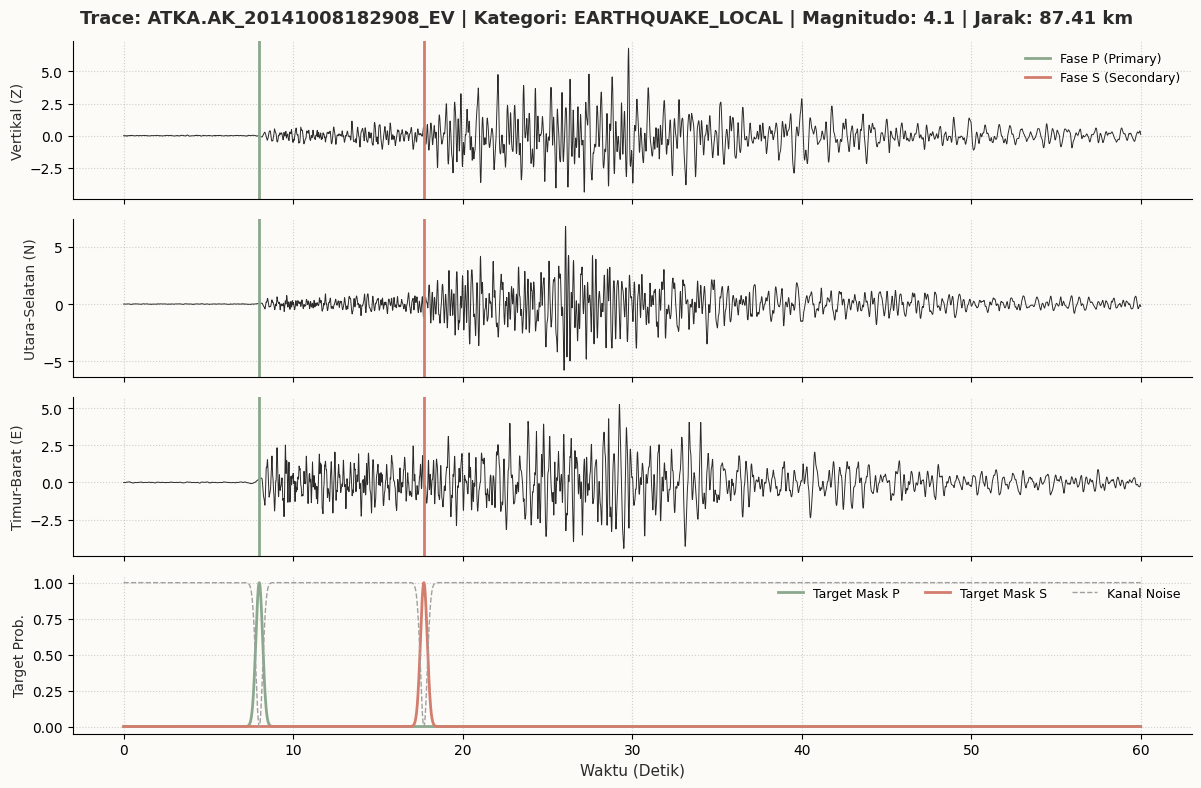


Visualisasi Sinyal Noise Murni


/tmp/ipykernel_3314/1321969072.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(loc='upper right', frameon=False, fontsize=9)


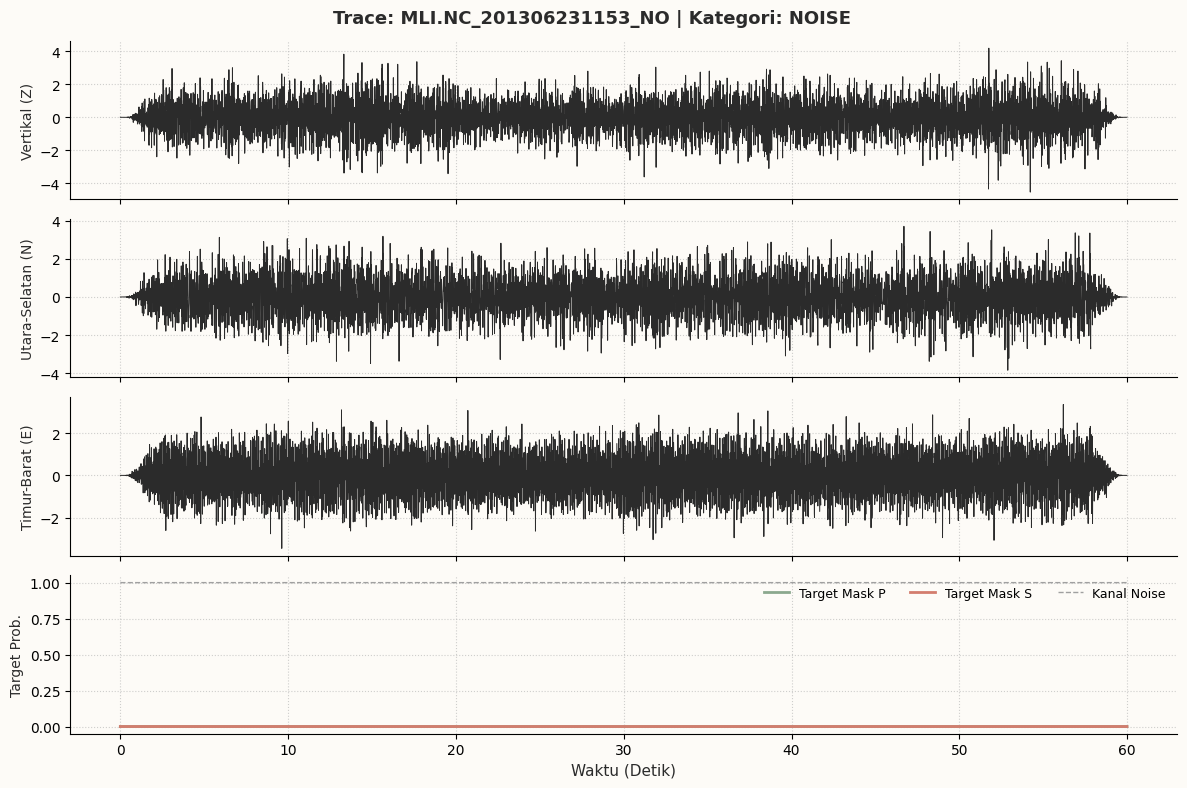

In [25]:
import matplotlib.pyplot as plt
def visualisasi_sampel_seismik(dataset, indeks_sampel):
    """
    Memvisualisasikan sinyal 3-komponen (Z, N, E) dan kurva target Gaussian
    """
    # Ekstrak data dari dataset (output sudah melalui DSP dan berbentuk Tensor)
    tensor_input, tensor_target = dataset[indeks_sampel]

    # Ambil salah satu baris metadata
    row = dataset.metadata_df.iloc[indeks_sampel]
    nama_trace = row['trace_name']
    kategori = row['trace_category']

    # Konversi tensor kembali ke array NumPy untuk plotting
    waveform = tensor_input.numpy()       # Shape: (3, 6000)
    target_mask = tensor_target.numpy()   # Shape: (3, 6000)

    # Sumbu waktu dengan 6000 titik dengan sampling rate 100 Hz = 60 detik
    time_axis = np.arange(waveform.shape[1]) / 100.0

    # Gaya visualisasi
    fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    fig.patch.set_facecolor('#FDFBF7')

    judul = f"Trace: {nama_trace} | Kategori: {kategori.upper()}"
    if kategori == 'earthquake_local':
        mag = row.get('source_magnitude', 'N/A')
        dist = row.get('source_distance_km', 'N/A')
        judul += f" | Magnitudo: {mag} | Jarak: {dist} km"

    fig.suptitle(judul, fontsize=13, fontweight='bold', color='#2B2B2B')

    kanal_labels = ['Vertikal (Z)', 'Utara-Selatan (N)', 'Timur-Barat (E)']

    # Plot 3 Kanal Gelombang Fisik
    for i in range(3):
        axs[i].plot(time_axis, waveform[i], color='#2B2B2B', linewidth=0.7)
        axs[i].set_ylabel(kanal_labels[i], fontsize=10, color='#2B2B2B')
        axs[i].set_facecolor('#FDFBF7')
        axs[i].grid(True, linestyle=':', alpha=0.6)
        axs[i].spines['top'].set_visible(False)
        axs[i].spines['right'].set_visible(False)

        #  penanda garis vertikal untuk kelas gempa
        if kategori == 'earthquake_local':
            p_sec = row['p_arrival_sample'] / 100.0
            s_sec = row['s_arrival_sample'] / 100.0
            axs[i].axvline(x=p_sec, color='#8BA88E', linestyle='-', linewidth=2, label='Fase P (Primary)' if i==0 else "")
            axs[i].axvline(x=s_sec, color='#D37D6E', linestyle='-', linewidth=2, label='Fase S (Secondary)' if i==0 else "")

    # Plot Kurva Target Gaussian (Ground Truth untuk U-Net)
    axs[3].plot(time_axis, target_mask[0], color='#8BA88E', linewidth=2, label='Target Mask P')
    axs[3].plot(time_axis, target_mask[1], color='#D37D6E', linewidth=2, label='Target Mask S')
    axs[3].plot(time_axis, target_mask[2], color='#A0A0A0', linewidth=1, linestyle='--', label='Kanal Noise')
    axs[3].set_ylabel('Target Prob.', fontsize=10, color='#2B2B2B')
    axs[3].set_xlabel('Waktu (Detik)', fontsize=11, color='#2B2B2B')
    axs[3].set_facecolor('#FDFBF7')
    axs[3].set_ylim(-0.05, 1.05)
    axs[3].grid(True, linestyle=':', alpha=0.6)
    axs[3].spines['top'].set_visible(False)
    axs[3].spines['right'].set_visible(False)

    # Legenda
    axs[0].legend(loc='upper right', frameon=False, fontsize=9)
    axs[3].legend(loc='upper right', frameon=False, ncol=3, fontsize=9)

    plt.tight_layout()
    plt.show()


# JALANKAN FUNGSINYA
idx_gempa = df_metadata[df_metadata['trace_category'] == 'earthquake_local'].index[0]
idx_noise = df_metadata[df_metadata['trace_category'] == 'noise'].index[0]

print("Visualisasi Sinyal Gempa Bumi")
visualisasi_sampel_seismik(master_dataset, idx_gempa)

print("\nVisualisasi Sinyal Noise Murni")
visualisasi_sampel_seismik(master_dataset, idx_noise)

## Splitting Data
Sebanyak 100.000 sampel data rekaman dibagi menjadi tiga kelompok, yaitu 70% Data Latih (Training), 15% Data Validasi (Validation), dan 15% Data Uji (Testing) menggunakan algoritma GroupShuffleSplit. Pembagian ini tidak diacak secara baris per baris, melainkan dikelompokkan secara utuh berdasarkan identitas kejadian gempa (group_id/source_id).  

Metode ini dipilih untuk mencegah kebocoran data (data leakage), mengingat getaran dari satu peristiwa gempa yang sama umumnya terekam oleh banyak stasiun sensor sekaligus. Jika data diacak biasa, model berisiko "menyontek" pola gempa yang sama di data latih dan data uji sehingga tampak akurat hanya karena menghafal (overfitting). Dengan pemisahan berbasis kejadian gempa, model diuji murni menggunakan gempa baru yang belum pernah dilihat sebelumnya, sehingga hasil evaluasinya mencerminkan performa nyata saat diterapkan di lapangan.

In [26]:
# Gempa kita kelompokkan pakai 'source_id', sementara  Noise pakai 'trace_name'
df_metadata['group_id'] = df_metadata['source_id'].fillna(df_metadata['trace_name'])

# Group Shuffle Split (Train 70% | Sisa 30%) berdasarkan Grup ID
gss_train = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
generator_split_1 = gss_train.split(df_metadata, groups=df_metadata['group_id'])
train_indices, temp_indices = next(generator_split_1)

"""
- Train Set (70%) sebagai data belajar untuk model AI
- Validation Set (15%) sebagai evaluasi dan untuk melihat perkembangan dan menyetel parameter)
- Test Set (15%) untuk menguji kemampuan AI setelah dilatih
"""
df_temp = df_metadata.iloc[temp_indices].copy()
gss_val_test = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
generator_split_2 = gss_val_test.split(df_temp, groups=df_temp['group_id'])

val_local_indices, test_local_indices = next(generator_split_2)

# Mengembalikan indeks lokal ke indeks global dari dataframe asli
val_indices = temp_indices[val_local_indices]
test_indices = temp_indices[test_local_indices]

print(f"Total Data  : {len(df_metadata)}")
print(f"Train Size  : {len(train_indices)} baris")
print(f"Val Size    : {len(val_indices)} baris")
print(f"Test Size   : {len(test_indices)} baris")

# Menghubungkan indeks ke instance Dataset menggunakan fitur Subset
train_data = Subset(master_dataset, train_indices)
val_data = Subset(master_dataset, val_indices)
test_data = Subset(master_dataset, test_indices)

#  Membungkus ke dalam DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("DONE")

Total Data  : 100000
Train Size  : 70016 baris
Val Size    : 14993 baris
Test Size   : 14991 baris
DONE


# 2.5 DESAIN ARSITEKTUR ENCODER-DECODER

Ada beberapa tahap yang kita lakukan di sub-bab ini:
- Blok Konvolusi Ganda (DoubleConv): Unit dasar yang memproses sinyal melalui dua lapis konvolusi 1D berukuran kernel 7, disertai Batch Normalization untuk menstabilkan angka dan fungsi aktivasi ReLU agar model mampu mempelajari pola getaran non-linear yang kompleks.  
- Sayap Kompresi / Encoder (Downsampling): Bertugas menyaring intisari bentuk gelombang secara bertahap dengan melipatgandakan kedalaman kanal fitur ($3 \rightarrow 16 \rightarrow 32 \rightarrow 64$) sambil membagi dua panjang sinyal di setiap tingkat menggunakan MaxPooling1D.  Inti Jaringan /
- Bottleneck: Lapisan terdalam (128 kanal) yang menyimpan ringkasan representasi sinyal paling padat, berfungsi memahami konteks besar apakah rekaman tersebut merupakan gempa utuh atau sekadar derau lingkungan.  
- Sayap Rekonstruksi / Decoder (Upsampling): Mengembalikan resolusi waktu sinyal ke panjang aslinya (6000 titik) menggunakan ConvTranspose1D secara bertahap ($128 \rightarrow 64 \rightarrow 32 \rightarrow 16$) agar posisi waktu tiba fase dapat dipetakan kembali dengan presisi.  
- Jalur Pintas / Skip Connections (torch.cat): Menempelkan salinan fitur resolusi tinggi dari Encoder langsung ke Decoder pada tingkat yang sejajar, memastikan model tidak kehilangan detail milidetik kedatangan gelombang akibat proses kompresi.  
- Lapisan Luaran / Output Layer: Menggunakan konvolusi $1\times1$ untuk mereduksi 16 fitur akhir menjadi 3 kanal logits (Gelombang P, Gelombang S, dan Noise) sepanjang 6000 titik sampel.

In [27]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            # kita coba dengan kernel size 7
            nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet1D(nn.Module):
    """
    Arsitektur Utama 1D U-Net untuk Segmentasi Sinyal Seismik.
    """
    def __init__(self, in_channels=3, out_channels=3):
        super(UNet1D, self).__init__()

        # ENCODER (untuk Merangkum Fitur)
        # input kanal awal adalah 3 (Z, N, E)
        self.down1 = DoubleConv(in_channels, 16)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.down2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.down3 = DoubleConv(32, 64)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)

        # BOTTLENECK (inti ekstrasi)
        self.bottleneck = DoubleConv(64, 128)

        # DECODER (Membangun Ulang)
        # Mengembalikan panjang sinyal (Upsample) sekaligus mengurangi kedalaman kanal
        self.upconv3 = nn.ConvTranspose1d(128, 64, kernel_size=2, stride=2)
        # 64 (dari bawah) + 64 (dari skip connection) = 128
        self.up3 = DoubleConv(128, 64)

        self.upconv2 = nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2)
        self.up2 = DoubleConv(64, 32)

        self.upconv1 = nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2)
        self.up1 = DoubleConv(32, 16)

        # OUTPUT LAYER
        # Mengubah 16 fitur kembali menjadi 3 probabilitas (P, S, Noise)
        self.out_conv = nn.Conv1d(16, out_channels, kernel_size=1)

    def forward(self, x):
        # Menjalankan Encoder & simpan salinan untuk Skip Connection
        x1 = self.down1(x)
        p1 = self.pool1(x1)

        x2 = self.down2(p1)
        p2 = self.pool2(x2)

        x3 = self.down3(p2)
        p3 = self.pool3(x3)

        # Inti jaringan
        bot = self.bottleneck(p3)

        #  Menjalankan Decoder & Gabungkan dengan Skip Connection
        up3 = self.upconv3(bot)
        # Menggabungkan memori lama (x3) dengan pemahaman baru (up3)
        merge3 = torch.cat([x3, up3], dim=1)
        out3 = self.up3(merge3)

        up2 = self.upconv2(out3)
        merge2 = torch.cat([x2, up2], dim=1)
        out2 = self.up2(merge2)

        up1 = self.upconv1(out2)
        merge1 = torch.cat([x1, up1], dim=1)
        out1 = self.up1(merge1)

        # Prediksi akhir berupa nilai mentah (logits)
        # Kita tidak pasang Sigmoid di sini karena akan disatukan dengan Loss Function nanti
        logits = self.out_conv(out1)

        return logits

    # Inisialisasi model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet1D(in_channels=3, out_channels=3).to(device)
print(f"perangkat: {device}")

perangkat: cuda


# 2.6 KONFIGURASI LOSS & OPTIMIZER
Kita akan menggunakan kombinasi loss function untuk memberitahu seberapa jauh tebakan model meleset. Loss function yang akan digunakan, yaitu:
- BCE(Binary Cross Entropy) untuk menilai probabilitas poin-per-poin
- Dice Loss, sangat peka terhadap seberapa tumpang-tindih area tebakan dengan jawaban aslinya.

Kombinasi ini cocok untuk masalah ketidakseimbangan, seperti mencari kurva P dan S (yang sangat kecil) di lautan sinyal bising.

Untuk Optimizer, kita akan menggunakan optimizer Adam, yang secara otomatis mempercepat laju belajar jika model sedang bingung, dan mengerem dengan halus jika sudah mendekati jawaban benar.

In [28]:
import torch.optim as optim

class BCEDiceLoss(nn.Module):
    """
    Kombinasi BCE Loss dan Dice Loss untuk presisi tinggi pada data yang tidak seimbang.
    """
    def __init__(self, bce_weight=0.5):
        super(BCEDiceLoss, self).__init__()
        self.bce_weight = bce_weight
        # BCEWithLogitsLoss lebih stabil secara numerik karena menggabungkan aktivasi Sigmoid
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred_logits, targets):
        # Hitung kerugian BCE (Berdasarkan nilai tebakan mentah)
        bce_loss = self.bce(pred_logits, targets)

        # Hitung kerugian Dice
        # Ubah logits menjadi probabilitas (0 hingga 1) menggunakan fungsi Sigmoid
        pred_probs = torch.sigmoid(pred_logits)

        # Mencegah error pembagian dengan nol menggunakan angka yang sangat kecil
        smooth = 1e-6

        # Mengukur area irisan tebakan dan target
        intersection = (pred_probs * targets).sum(dim=2)

        # Mengukur total luas area keduanya
        union = pred_probs.sum(dim=2) + targets.sum(dim=2)

        # Rumus Dice Coefficient
        dice_score = (2. * intersection + smooth) / (union + smooth)
        dice_loss = 1 - dice_score.mean()

        total_loss = (self.bce_weight * bce_loss) + ((1 - self.bce_weight) * dice_loss)
        return total_loss

# Inisialisasi BCEDiceLoss
criterion = BCEDiceLoss(bce_weight=0.5)

# Inisialisasi optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)



In [29]:
"""
Kita aka menerapkan learning rate scheduler untuk memantau pergerakan loss. Untuk kasus deteksi
dase seismik , algoritma yang akan kita gunakan adalah ReduceLROnPlateu.
Jika model mulai stagnan (plateau), sistem akan otomatis mengecilkan learning rate.
Langkah yang lebih halus ini memungkinkan model melakukan fine-tuning bobot secara presisi.
"""

from torch.optim.lr_scheduler import ReduceLROnPlateau

# Inisialisasi Penjadwal Learning Rate Dinamis
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# 2.7 TRAINING & VALIDATION LOOP
Di tahap ini, model akan mencoba menjawab semua pertanyaan latihan (train_loader), mengukur kesalahannya, lalu memutar otak untuk memperbaiki weights-nya (loss.backward() dan optimizer.step()). Setelah itu, model akan langsung dites kecil-kecilan menggunakan val_loader. Jika nilai ujian validasi lebih bagus dari sebelum-sebelumnya, kita simpan model terbaiknya menjadi sebuah file .pt sehingga kita selalu punya versi terbaik dari model kita. Kita juga menereapkan 'early stopping' jika performa train dan validation model tidak meningkat lagi

In [30]:
import time
import os

#  Direktori Penyimpanan Model
save_dir = "/content/drive/MyDrive/Model_Seismik"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_unet_seismic.pt")

# Konfigurasi Early Stopping & Epochs
max_epochs = 30
patience = 5
patience_counter = 0
best_val_loss = float('inf')

# Inisialisasi wadah untuk riwayat loss
history = {
    'train_loss': [],
    'val_loss': []
}

print("Proses Training.....")

for epoch in range(max_epochs):
    start_time = time.time()

    # FASE PELATIHAN (TRAIN)
    model.train()
    train_loss = 0.0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        predictions = model(inputs)
        loss = criterion(predictions, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # FASE EVALUASI (VALIDATION)
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            predictions = model(inputs)
            loss = criterion(predictions, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # update learning rate
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Simpan nilai rata-rata loss epoch saat ini
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)


    # LOGIKA EARLY STOPPING
    elapsed_time = time.time() - start_time

    print(f"Epoch {epoch+1:03d}/{max_epochs} | Waktu: {elapsed_time:.1f}s | LR: {current_lr:.6f}")
    print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Bobot baru disimpan (counter direset)")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEARLY STOPPING  PADA EPOCH {epoch+1}!")
            print(f"Model terbaik ada pada Val Loss: {best_val_loss:.4f}")
            break

print("DONE")

Proses Training.....
Epoch 001/30 | Waktu: 140.7s | LR: 0.001000
   Train Loss: 0.2614 | Val Loss: 0.2199
Bobot baru disimpan (counter direset)
Epoch 002/30 | Waktu: 130.8s | LR: 0.001000
   Train Loss: 0.2202 | Val Loss: 0.2192
Bobot baru disimpan (counter direset)
Epoch 003/30 | Waktu: 131.0s | LR: 0.001000
   Train Loss: 0.2191 | Val Loss: 0.2179
Bobot baru disimpan (counter direset)
Epoch 004/30 | Waktu: 129.8s | LR: 0.001000
   Train Loss: 0.2184 | Val Loss: 0.2172
Bobot baru disimpan (counter direset)
Epoch 005/30 | Waktu: 131.4s | LR: 0.001000
   Train Loss: 0.1558 | Val Loss: 0.0724
Bobot baru disimpan (counter direset)
Epoch 006/30 | Waktu: 130.1s | LR: 0.001000
   Train Loss: 0.0707 | Val Loss: 0.0679
Bobot baru disimpan (counter direset)
Epoch 007/30 | Waktu: 129.6s | LR: 0.001000
   Train Loss: 0.0689 | Val Loss: 0.0679
Patience: 1/5
Epoch 008/30 | Waktu: 130.1s | LR: 0.001000
   Train Loss: 0.0687 | Val Loss: 0.0688
Patience: 2/5
Epoch 009/30 | Waktu: 131.4s | LR: 0.000500

# 2.8 INFERENCE ON THE TEST SET
Kita akan menjalankan model pada seluruh data ujian (Test Set) dengan mematikan fungsi latihan (model.eval()) dan menghentikan perekaman gradien (torch.no_grad()) agar komputer bekerja cepat dan hemat memori. Tujuan utamanya untuk Menghasilkan matriks prediksi probabilitas mentah berskala 0.0 hingga 1.0 untuk seluruh 14.991 sampel data uji.

In [ ]:
def jalankan_inferensi(model, test_loader, device):
    """
    Fungsi untuk menjalankan tebakan model pada seluruh Test Set.
    Mengembalikan array numpy berisi tebakan dan kunci jawaban.
    """

    """
    model.eval(): Perintah untuk mengaktifkan mode evaluasi pada model.
    Fungsinya adalah mengunci bobot model serta menonaktifkan fitur pelatihan (seperti Dropout dan Batch Normalization),
    sehingga hasil tebakan model bersifat stabil dan konsisten.
    """

    model.eval()

    # Wadah untuk menyimpan seluruh tebakan dan kunci jawaban
    semua_tebakan = []
    semua_target = []

    """
    torch.no_grad(): Perintah untuk mematikan mesin pelacak gradien/turunan matematis.
    Fungsinya adalah menghemat penggunaan memori RAM/GPU
    dan mempercepat proses komputasi karena model hanya bertugas menebak tanpa perlu belajar lagi.
    """
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(test_loader):
            inputs = inputs.to(device)

            # Prediction (outputnya masih berupa angka mentah/logits)
            logits = model(inputs)

            # Ubah angka mentah menjadi persentase probabilitas (0.0 - 1.0)
            probabilitas = torch.sigmoid(logits)

            """
            Perintah .cpu() wajib digunakan sebelum .numpy()
            karena pustaka NumPy tidak dapat membaca memori kartu grafis (GPU).
            NumPy dirancang hanya untuk memproses data yang berada di memori utama komputer (RAM/CPU).
            """
            semua_tebakan.append(probabilitas.cpu().numpy())
            semua_target.append(targets.numpy())


            if (batch_idx + 1) % 50 == 0:
                print(f" inferensi batch {batch_idx + 1}...")

    # Gabungkan semua potongan list menjadi satu matriks
    matriks_tebakan = np.concatenate(semua_tebakan, axis=0)
    matriks_target = np.concatenate(semua_target, axis=0)

    print("Inferensi Selesai")
    print(f"Bentuk Matriks Tebakan: {matriks_tebakan.shape}")
    # output shape: (Total Data Test, 3 Kanal, 6000 Sampel)

    return matriks_tebakan, matriks_target


# untuk kebutuhan deployment
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))

# menjalankan fungsi
prediksi_uji, target_uji = jalankan_inferensi(model, test_loader, device)

 inferensi batch 50...
 inferensi batch 100...
 inferensi batch 150...
 inferensi batch 200...
 inferensi batch 250...
 inferensi batch 300...
 inferensi batch 350...
 inferensi batch 400...
 inferensi batch 450...
Inferensi Selesai
Bentuk Matriks Tebakan: (14991, 3, 6000)


# 2.9 PEAK DETECTION ALGORITHM
Kita akan mengubah grafik lengkungan peluang (probabilitas) hasil tebakan model menjadi satu angka pasti yang menunjukkan detik kedatangan gelombang. Kita akan tentukan dengan thresholds 0.5, model hanya akan mencatat waktu kedatangan gempa jika nilai probabilitas puncak nya lebih dari sama dengan 0.5

In [32]:
# Fungsi ini mencari indeks (posisi waktu) dari puncak probabilitas tertinggi.
def temukan_puncak_kurva(array_probabilitas, threshold=0.5):
    """
    Input: Array 1D panjang 6000 (probabilitas 1 kanal spesifik per rekaman)
    Output: Angka indeks (integer) atau NaN jika tidak ada yang melewati threshold.
    """
    # Cari berapa probabilitas paling tinggi di dalam rentang 6000 titik ini
    nilai_tertinggi = np.max(array_probabilitas)
    if nilai_tertinggi >= threshold:
        indeks_puncak = np.argmax(array_probabilitas)
        return float(indeks_puncak)
    else:
        # Jika probabilitasnya rendah semua, anggap tidak ada kedatangan P/S
        return np.nan

# Fungsi untuk mencari puncak untuk seluruh data uji (Batch)
def proses_seluruh_puncak(matriks_probabilitas, matriks_target, threshold=0.5):

    total_data = matriks_probabilitas.shape[0]

    # list kosong untuk P dan S
    pred_P, pred_S = [], []
    aktual_P, aktual_S = [], []

    for i in range(total_data):
        # Kanal 0 = Gelombang P, Kanal 1 = Gelombang S
        prob_P = matriks_probabilitas[i, 0, :]
        prob_S = matriks_probabilitas[i, 1, :]

        target_P = matriks_target[i, 0, :]
        target_S = matriks_target[i, 1, :]

        # Ekstrak titik prediksi model
        pred_P.append(temukan_puncak_kurva(prob_P, threshold))
        pred_S.append(temukan_puncak_kurva(prob_S, threshold))

        # Ekstrak titik aktual
        aktual_P.append(temukan_puncak_kurva(target_P, threshold))
        aktual_S.append(temukan_puncak_kurva(target_S, threshold))

    return np.array(pred_P), np.array(pred_S), np.array(aktual_P), np.array(aktual_S)

# Eksekusi pencarian puncak untuk gelombang P dan S
(titik_pred_P, titik_pred_S, titik_aktual_P, titik_aktual_S) = proses_seluruh_puncak(prediksi_uji, target_uji, threshold=0.5)

print("DONE")

DONE


# 2.10 VISUALISASI GRAFIK EVALUASI MODEL
Ada 2 kurva yang akan kita buat:
- Kurva Pembelajaran (Learning Curve), Grafik garis yang menampilkan penurunan nilai kerugian (Loss) pada data latih (Train Loss) dan data validasi (Val Loss) di setiap putaran belajar (Epoch). Grafik ini digunakan untuk memastikan model mengalami proses konvergensi secara stabil tanpa mengalami penghafalan data berlebih (overfitting).
- Visualisasi yang menampilkan grafik getaran fisik 3-komponen ($Z, N, E$) pada baris atas, serta tumpang tindih (overlay) kurva target asli (Ground Truth) dan kurva probabilitas prediksi model pada baris bawah. Tujuannya untuk melihat apakah puncak prediksi model jatuh tepat di atas awal lonjakan gelombang seismik fisik.

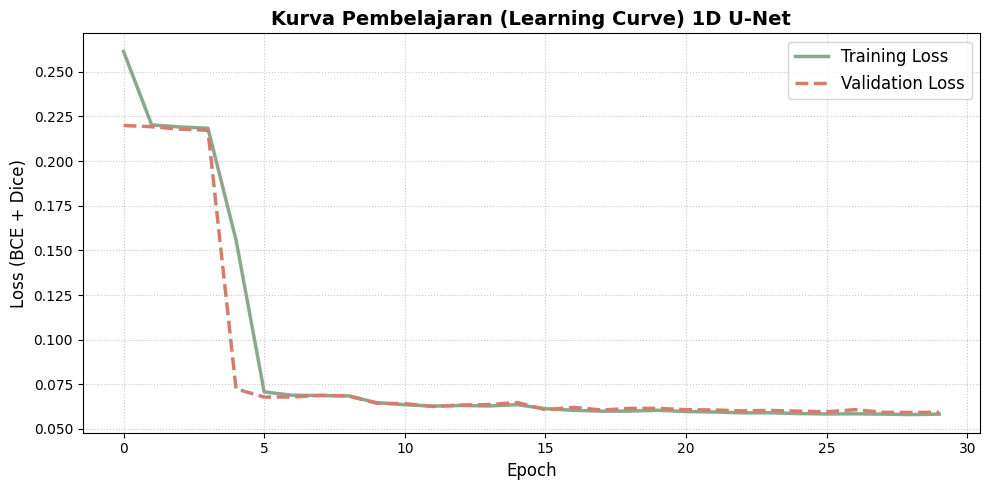

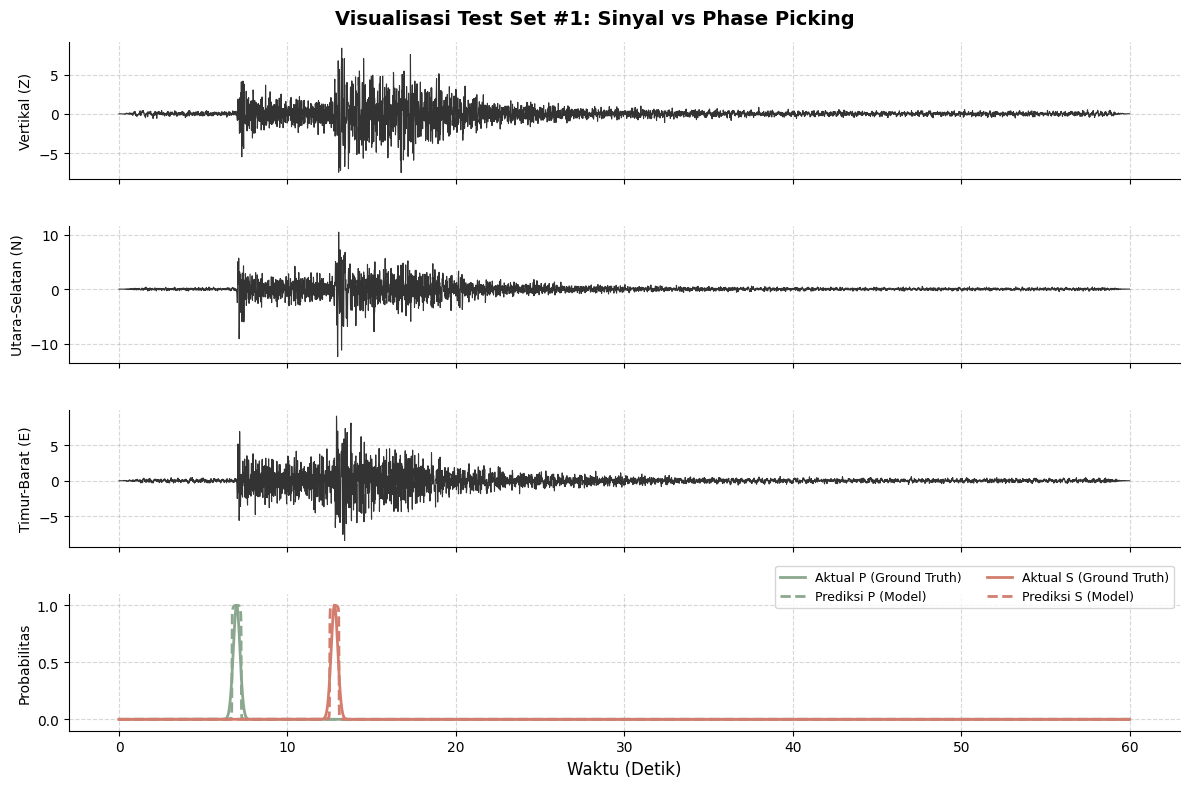

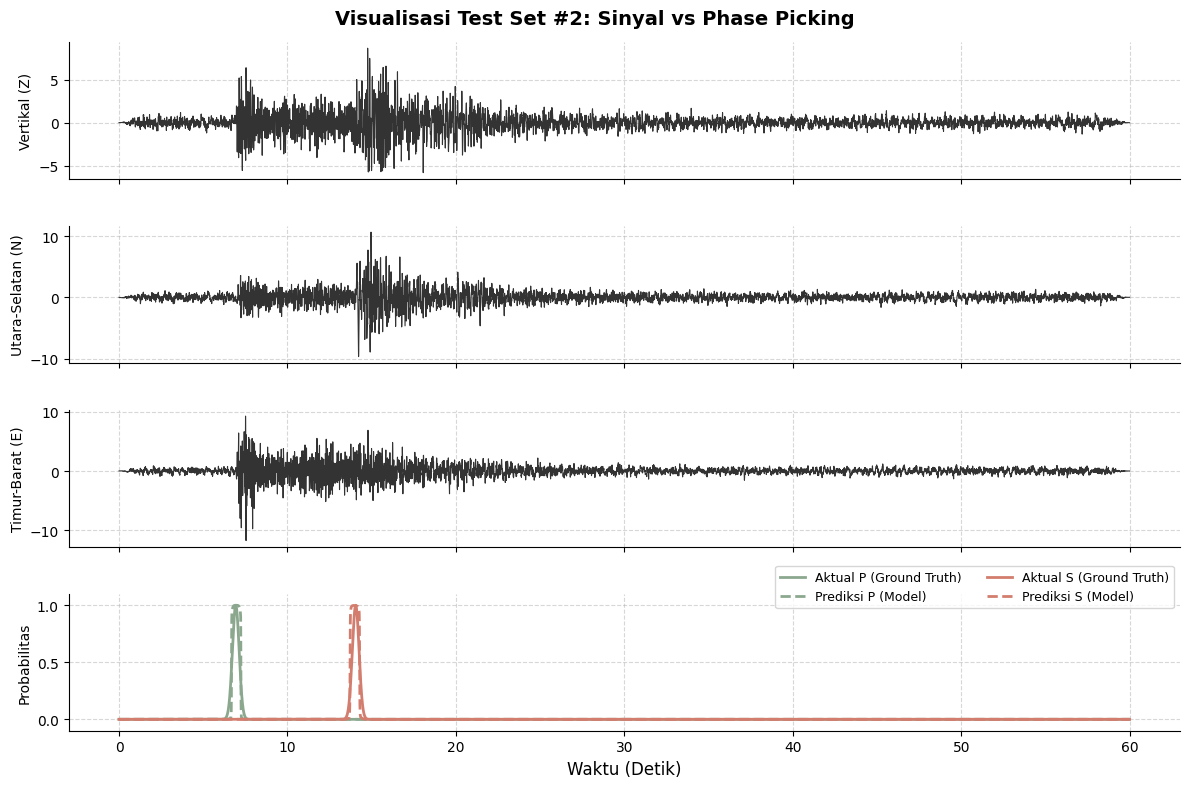

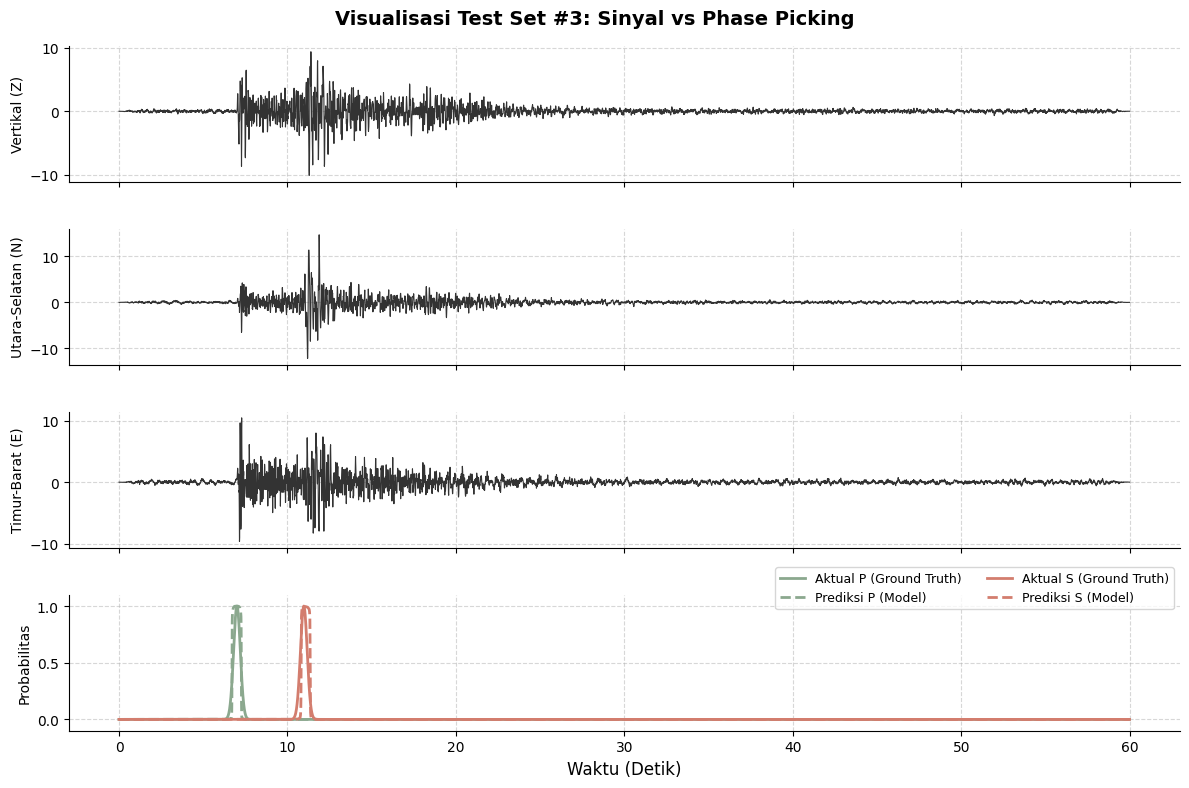

In [33]:
# Fungsi untuk menampilkan grafik pergerakan Loss selama proses training.
def plot_learning_curve(history):
    plt.figure(figsize=(10, 5))

    plt.plot(history['train_loss'], label='Training Loss', color='#8BA88E', linewidth=2.5)
    plt.plot(history['val_loss'], label='Validation Loss', color='#D37D6E', linewidth=2.5, linestyle='--')

    plt.title('Kurva Pembelajaran (Learning Curve) 1D U-Net', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (BCE + Dice)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()


def plot_actual_vs_pred_samples(model, test_loader, device, num_samples=3):
    """
    Menarik beberapa sampel dari Test Set, melakukan inferensi,
    lalu memplot gelombang asli beserta kurva Aktual vs Prediksi.
    """
    model.eval()

    # ambil 1 batch pertama dari test_loader untuk visualisasi
    inputs, targets = next(iter(test_loader))
    inputs = inputs.to(device)

    with torch.no_grad():
        logits = model(inputs)
        probs = torch.sigmoid(logits).cpu().numpy()

    inputs = inputs.cpu().numpy()
    targets = targets.numpy()

    # Sumbu X dalam skala detik (6000 sampel / 100 Hz = 60 detik)
    time_axis = np.arange(6000) / 100.0
    kanal_nama = ['Vertikal (Z)', 'Utara-Selatan (N)', 'Timur-Barat (E)']

    for i in range(num_samples):
        fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
        fig.suptitle(f'Visualisasi Test Set #{i+1}: Sinyal vs Phase Picking', fontsize=14, fontweight='bold')

        # Plot 3 Kanal Gelombang Asli
        for c in range(3):
            axs[c].plot(time_axis, inputs[i, c, :], color='#333333', linewidth=0.8)
            axs[c].set_ylabel(kanal_nama[c], fontsize=10)
            axs[c].grid(True, linestyle='--', alpha=0.5)
            axs[c].spines['top'].set_visible(False)
            axs[c].spines['right'].set_visible(False)

        # Plot Kurva Probabilitas P dan S (Aktual vs Prediksi)
        axs[3].plot(time_axis, targets[i, 0, :], color='#8BA88E', linestyle='-', linewidth=2, label='Aktual P (Ground Truth)')
        axs[3].plot(time_axis, probs[i, 0, :], color='#8BA88E', linestyle='--', linewidth=2, label='Prediksi P (Model)')

        axs[3].plot(time_axis, targets[i, 1, :], color='#D37D6E', linestyle='-', linewidth=2, label='Aktual S (Ground Truth)')
        axs[3].plot(time_axis, probs[i, 1, :], color='#D37D6E', linestyle='--', linewidth=2, label='Prediksi S (Model)')

        axs[3].set_ylabel('Probabilitas', fontsize=10)
        axs[3].set_xlabel('Waktu (Detik)', fontsize=12)
        axs[3].set_ylim(-0.1, 1.1)
        axs[3].legend(loc='upper right', bbox_to_anchor=(1.0, 1.25), ncol=2, fontsize=9)
        axs[3].grid(True, linestyle='--', alpha=0.5)
        axs[3].spines['top'].set_visible(False)
        axs[3].spines['right'].set_visible(False)

        plt.tight_layout()
        plt.show()

plot_learning_curve(history)
plot_actual_vs_pred_samples(model, test_loader, device, num_samples=3)

# 2.11 METRIC EVALUATION

Kita akan menggunakan kombinasi **F1-Score dan MAE** sebagai metrik evaluasi. 2 metrik ini dipilih karena sistem peringatan dini gempa menyelesaikan 2 tugas utama, yaitu mendeteksi gelombang(klasifikasi) dan ketepatan hitungan detik kedatangan(regresi waktu).

**F1-Score** menggabungkan 2 aspek krusial, yaitu:
- Precision, untuk memastikan sistem tidak panik membunyikan sirene bahaya saat yang terekam hanyalah getaran truk lewat atau derau instrumen (Noise).
- Recall, untuk memastikan tidak ada peristiwa gempa bumi sungguhan yang gagal tertangkap oleh sensor.

Dalam 60 detik rekaman (6000 titik), titik tiba gelombang hanya berupa satu garis sangat sempit, sementara sisanya adalah noise. Jika model selalu menebak "tidak ada gelombang", akurasi biasanya tetap di atas 95%, padahal model tersebut gagal total. F1-Score hanya memberi nilai jika model benar-benar berhasil menemukan titik sasaran gelombang.

metrik evaluasi **MAE** juga dipilih karena MAE menghitung rata-rata deviasi mutlak antara detik tebakan model dan detik kedatangan aktual dalam satuan waktu konkret (detik atau milidetik). Selain itu gelombang seismik merambat dengan kecepatan $6 - 8\text{ km/detik}$. Kesalahan waktu sekecil $0.1$ detik saja bisa menggeser estimasi posisi patahan gempa ratusan meter hingga kilometer. MAE memberikan gambaran langsung seberapa presisi data waktu ini jika diteruskan ke algoritma pelacak lokasi gempa (triangulasi hiposenter).

In [37]:
def hitung_metrik_seismik(prediksi, aktual, toleransi_sampel=50):
    """
    Menghitung MAE (detik) dan F1-Score.
    toleransi_sampel = 50 berarti tebakan dianggap benar (TP) jika meleset maksimal 0.5 detik.
    """
    tp = 0
    fp = 0
    fn = 0

    total_error_sampel = 0.0

    for p, a in zip(prediksi, aktual):
        # Kondisi 1: Ada target asli (Gelombang P/S benar-benar ada)
        if not np.isnan(a):
            if not np.isnan(p):
                # Model menebak ada. kita cek jarak error-nya
                error_mutlak = abs(p - a)

                if error_mutlak <= toleransi_sampel:
                    # Masuk dalam batas toleransi. Ini merupakan titik gempa
                    tp += 1
                    total_error_sampel += error_mutlak
                else:
                    # Tebak ada, tapi kejauhan jarak waktunya
                    fp += 1
                    fn += 1 # Kunci jawaban aslinya terlewat
            else:
                # Kunci jawaban ada, tapi model bilang tidak ada
                fn += 1

        # Kondisi 2: Kunci jawaban kosong (Harusnya ini murni Noise)
        else:
            if not np.isnan(p):
                # Model menebak ada gelombang padahal ini noise (Halusinasi/Alarm Palsu)
                fp += 1
            else:
                # Kunci kosong, model nebak kosong. Benar, tapi biasanya tidak masuk metrik TP.
                # Ini True Negative (TN), tapi tidak dipakai untuk F1-Score dan MAE.
                pass

    # Kalkulasi Metrik F1-Score
    # Mencegah error pembagian dengan nol
    presisi = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = 2 * (presisi * recall) / (presisi + recall) if (presisi + recall) > 0 else 0.0

    # Kalkulasi MAE (hanya untuk data yang ditebak dengan benar secara area TP)
    mae_sampel = total_error_sampel / tp if tp > 0 else 0.0

    # Frekuensi sampel kita adalah 100 Hz. Jadi 100 sampel = 1 detik.
    mae_detik = mae_sampel / 100.0

    return f1_score, mae_detik

print("EVALUASI MODEL (TEST SET)")

# Hitung untuk Fase P
f1_P, mae_P = hitung_metrik_seismik(titik_pred_P, titik_aktual_P)
print("\n[GELOMBANG P - PRIMARY]")
print(f"F1-Score : {f1_P:.4f} (Seberapa akurat deteksinya)")
print(f"MAE      : {mae_P:.4f} Detik (Seberapa meleset waktu ketibaannya)")

# Hitung untuk Fase S
f1_S, mae_S = hitung_metrik_seismik(titik_pred_S, titik_aktual_S)
print("\n[GELOMBANG S - SECONDARY]")
print(f"F1-Score : {f1_S:.4f} (Seberapa akurat deteksinya)")
print(f"MAE      : {mae_S:.4f} Detik (Seberapa meleset waktu ketibaannya)")
print("-" * 40)

EVALUASI MODEL (TEST SET)

[GELOMBANG P - PRIMARY]
F1-Score : 0.9652 (Seberapa akurat deteksinya)
MAE      : 0.0356 Detik (Seberapa meleset waktu ketibaannya)

[GELOMBANG S - SECONDARY]
F1-Score : 0.9487 (Seberapa akurat deteksinya)
MAE      : 0.0580 Detik (Seberapa meleset waktu ketibaannya)
----------------------------------------


## Pembahasan Hasil Prediksi

<div style="background-color:#f0f8ff; color:#111111; padding:15px; border-radius:8px;">

**ANALISIS GELOMBANG PRIMER**  
F1-Score ($0.9652$) menunjukkan Tingkat deteksi berada di level luar biasa. Model nyaris tidak mengalami false alarm terhadap rekaman derau (noise) dan hampir tidak pernah melewatkan peristiwa gempa bumi lokal.  

MAE ($35.6\text{ ms}$) Pada frekuensi sampling $100\text{ Hz}$ (1 data poin $= 10\text{ ms}$), selisih rata-rata hanya meleset sekitar $3.5$ titik data. Dengan kecepatan rambat gelombang primer di kerak bumi ($V_p \approx 6\text{ km/s}$), deviasi waktu $0.0356$ detik hanya menghasilkan ketidakpastian jarak hiposenter sebesar $\approx 213\text{ meter}$. Ini sangat baik untuk kebutuhan penentuan lokasi episenter darurat.  

</div>

<div style="background-color:#fffacd; color:#111111; padding:15px; border-radius:8px;">

**ANALISIS GELOMBANG SEKUNDER**  
F1-Score sebesar 0.9487 menunjukkan bahwa untuk menangkap fase S jauh lebih menantang karena gelombang ini tiba saat tanah masih bergetar akibat ekor gelombang P (P-wave coda). Skor di atas 94% membuktikan representasi konvolusi Encoder mampu membedakan frekuensi geser dari sisa energi kompresi sebelumnya.  

MAE sebesar 58 ms menunjukkan selisih rata-rata di bawah 0.06 detik yang menunjukkan hasil yang sangat baik. Hal ini berada jauh di ambang batas kritis industri (100 ms), memastikan kalkulasi selisih waktu tiba (Ts - Tp) untuk estimasi jarak episenter tunggal stasiun tetap akurat.  

</div>

<div style="background-color:#e6ffe6; color:#111111; padding:15px; border-radius:8px;">

**KESIMPULAN**  
Model mempertahankan rasio kesalahan alami, yaitu $\text{MAE}_P\ (35.6\text{ ms}) < \text{MAE}_S\ (58.0\text{ ms})$. Hal ini mengartikan ketajaman model untuk memprediksi gelombang P yang lebih tegas dibanding gelombang S terbaca dengan benar secara matematis oleh fungsi BCEDiceLoss, menegaskan bahwa model mempelajari fisika gelombang asli dan tidak mengalami bias memorisasi (data leakage). Oleh karena itu model ini layak dipakai untuk sistem peringatan dini gempa.  

</div>


In [ ]:
# untuk kebutuhan deployment

# Buat folder khusus untuk menyimpan sampel data ringan
sample_dir = "/content/drive/MyDrive/Model_Seismik/sample_data"
os.makedirs(sample_dir, exist_ok=True)

# Cari 1 sampel gempa dengan magnitudo yang lumayan besar dari Test Set
test_metadata = df_metadata.iloc[test_indices]
gempa_samples = test_metadata[
    (test_metadata['trace_category'] == 'earthquake_local') & 
    (test_metadata['source_magnitude'] >= 3.0)
]

# Ambil baris pertama dari hasil filter
contoh_gempa = gempa_samples.iloc[0]
nama_trace_gempa = contoh_gempa['trace_name']

# Cari 1 sampel Noise murni
noise_samples = test_metadata[test_metadata['trace_category'] == 'noise']
contoh_noise = noise_samples.iloc[0]
nama_trace_noise = contoh_noise['trace_name']

# Ekstrak gelombang mentah langsung dari HDF5
with h5py.File(HDF5_DRIVE_PATH, 'r') as hdf5_file:
    # Mengambil gelombang gempa dan transpose ke (3, 6000)
    gelombang_gempa = np.array(hdf5_file[f"data/{nama_trace_gempa}"]).T
    # Mengambil gelombang noise dan transpose ke (3, 6000)
    gelombang_noise = np.array(hdf5_file[f"data/{nama_trace_noise}"]).T

path_gempa = os.path.join(sample_dir, "simulasi_gempa.npy")
path_noise = os.path.join(sample_dir, "simulasi_noise.npy")

np.save(path_gempa, gelombang_gempa)
np.save(path_noise, gelombang_noise)

print(f"menyimpan {path_gempa} (M={contoh_gempa['source_magnitude']})")
print(f"menyimpan {path_noise}")